<h1 style="text-align:center;">Ito Calculus<br></h1>
<div style="text-align:center;">Ariel Kalingking</div>
<div style="text-align:center;">akalingking@gmail.com</div>
<div style="text-align:center;">Appendix: Python Code</div>

In [5]:
import math
import numpy as np
import statsmodels.api as sm
import logging
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

plt_inline_enable = False # Turn this off when running makefile
imagepath = "../paper/figures/"
figsize = (4,3)
fontbig = 9
fontmed = 8
fontsmall = 6

matplotlib.use('TkAgg')
logging.getLogger().setLevel(logging.ERROR)
if plt_inline_enable:
    %matplotlib inline

In [3]:
np.random.seed(18)
T = 1.0       # Time horizon, 1 year
N = 252       # Number of steps, trading days
dt = T/N      # Time interval
X_0 = 1.0     # Keep small since we deal with exponential terms in f(X_t,t)
# Define data vectors
Xt = np.zeros(N)
dW = np.zeros(N)  
f_Xt = np.zeros(N)
# Set initial values
Xt[0] = X_0
f_Xt[0] = X_0
time = np.full(N, dt).cumsum()

# Simulate df(t, X_t) path using Euler-Maruyama
# df(t,X) = (0.14tx^2 + X^2)dt + 0.4tx^2 dWt
# where:
#   mu = 0.14tx^2 + X^2
#   sigma = 0.4 tx^2
for i in range(N-1):
    # Brownian step
    dW[i] = np.sqrt(dt) * np.random.randn()
    # Price
    dXt =  0.05*Xt[i]*dt + 0.2*Xt[i]*dW[i]
    Xt[i+1] = Xt[i] + dXt
    
    # Trade strategy
    drift = (0.14 * time[i] * f_Xt[i]**2) + f_Xt[i]**2
    diff = 0.4 * time[i] * f_Xt[i]**2
    df_Xt = drift*dt + diff * dW[i]
    f_Xt[i+1] = f_Xt[i] + df_Xt

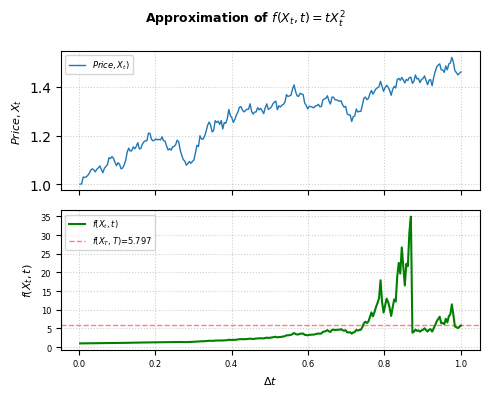

In [7]:
fig, (ax1,ax2) =  plt.subplots(2,1,figsize=(5,4), sharex=True)
ax1.plot(time, Xt, label=r"$Price, X_t)$", linewidth=1)
ax1.set_ylabel('$Price, X_t$', fontsize=fontmed)
ax1.legend(loc="best",fontsize=fontsmall)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(time, f_Xt, label=r"$f(X_t,t)$", color="green", linewidth=1.5)
#ax2.plot(time[0], X_0, 'o')
#ax2.plot(time[-1], f_Xt[-1], 'o')
ax2.axhline(f_Xt[-1], color="red", linestyle="--", linewidth=1.0, alpha=0.5, label=f"$f(X_T, T)$={f_Xt[-1]:.3f}")
ax2.set_ylabel('$f(X_t,t)$', fontsize=fontmed)
ax2.legend(loc="best",fontsize=fontsmall)
ax2.grid(True, linestyle=':', alpha=0.6)
plt.suptitle(r"Approximation of $f(X_t,t)=tX_t^2$", fontsize=fontbig,fontweight="bold")
plt.tick_params(axis='both', which='major', labelsize=fontsmall) 
plt.xlabel('$\Delta t$', fontsize=fontmed)
plt.tight_layout()
plt.savefig(imagepath+"itos_lemma_1.pdf", bbox_inches="tight")
if plt_inline_enable:
    plt.show()